# NeuMF with Attention-Weighted Sub-Ratings (variant B)

I extend Neural Matrix Factorization (He et al., WWW 2017) with a per-user
attention layer over six hotel sub-rating aspects (Service, Cleanliness,
Location, Value, Rooms, Sleep Quality). The goal is to convert these
fixed per-item aspect averages into a single attention-weighted “quality
score,” which is then fused with the GMF and MLP branches before the final
prediction.

In this notebook, I compare the **vanilla** NeuMF (GMF + MLP, no attention)
against the **enhanced** NeuMF-Attn (with the sub-rating attention head).
I load the saved artefacts from `results/neumf_attn/` and
`results/neumf_vanilla/`, and reproduce the same comparison tables used
across the other variants for consistency.


In [1]:
import json, os
from pathlib import Path

import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").is_dir() and (cand / "results").is_dir():
            return cand
    raise RuntimeError(f"Couldn't find repo root from {start}")

REPO = find_repo_root(Path.cwd())
RES_BASE = REPO / "results" / "baselines"
RES_NEU  = REPO / "results" / "neumf_attn"
RES_VAN  = REPO / "results" / "neumf_vanilla"
LOGS_NEU = REPO / "logs"    / "neumf_attn"
LOGS_VAN = REPO / "logs"    / "neumf_vanilla"
print("Repo:", REPO)
for p in [RES_BASE, RES_NEU, RES_VAN, LOGS_NEU, LOGS_VAN]:
    print(f"  {'OK' if p.exists() else '--'}  {p}")

def load_json(rel):
    return json.loads((REPO / rel).read_text())

def pick_run_suffix(res_dir: Path) -> str:
    for f in res_dir.glob("test_metrics_*.json"):
        return f.stem.replace("test_metrics_", "")
    raise FileNotFoundError(f"No test_metrics_*.json in {res_dir}")

RUN_NEU = pick_run_suffix(RES_NEU)
RUN_VAN = pick_run_suffix(RES_VAN)
print("Enhanced run suffix:", RUN_NEU)
print("Vanilla  run suffix:", RUN_VAN)


Repo: C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\baselines
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\neumf_attn
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\neumf_vanilla
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\logs\neumf_attn
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\logs\neumf_vanilla
Enhanced run suffix: gmf64_mlp64
Vanilla  run suffix: gmf64_mlp64


## 1. Architecture

```
user_id ──► gmf_user_emb ─┐
item_id ──► gmf_item_emb ─┴─► ⊙  ──► (B, gmf_dim)                          ┐
                                                                            │
user_id ──► mlp_user_emb ─┐                                                 │
item_id ──► mlp_item_emb ─┴─► concat ──► [Linear→ReLU→Dropout]×3 ──►  ────┐ │
                                                     (B, 64)              │ ├─► concat ─► Linear ─► score
                                                                          │ │
item_aspects[item_id] ──► (B, 6)                                          │ │   (vanilla skips
                           │                                              │ │    the qs branch
gmf_user_emb ─► attn_proj ─► softmax ─► (B, 6) ──►  ⊙ ─► sum ─► (B, 1) ───┘ │    entirely)
                                                 quality_score             ┘
```

- **GMF branch** dominates the fused representation with 64-dim element-wise product.
- **MLP branch** adds a deep interaction (`[256, 128, 64]`) over concatenated embeddings.
- **Sub-rating attention** projects the user's GMF embedding to 6 aspect logits,
  softmaxes them, and dot-products with the hotel's pre-computed aspect means.
  Disabled when `use_attention=False`.
- Item aspect vectors are computed on **train rows only** to avoid leakage;
  missing entries are filled with the train-split global mean per column.

Loss: BPR with 4 sampled negatives per positive. Evaluation: shared 1-vs-99.


## 2. Vanilla vs Enhanced - head-to-head

The two configs (`configs/neumf_vanilla.yaml` vs `configs/neumf_attn.yaml`)
differ only in `model.use_attention`. Same dataset, same seed, same
hyperparameters, same negative sampler.


In [2]:
enh = load_json(f"results/neumf_attn/test_metrics_{RUN_NEU}.json")
van = load_json(f"results/neumf_vanilla/test_metrics_{RUN_VAN}.json")
metric_keys = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]

rows = pd.DataFrame({
    "Vanilla NeuMF":         {k: van[k] for k in metric_keys},
    "Enhanced NeuMF-Attn":   {k: enh[k] for k in metric_keys},
})
rows.loc["Δ (enh - van)"] = rows["Enhanced NeuMF-Attn"] - rows["Vanilla NeuMF"]
rows = rows.T  # rows = variant, cols = metric
rows.style.format("{:.4f}")


,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20,Δ (enh - van)
Vanilla NeuMF,0.5978,0.7254,0.8468,0.4815,0.5228,0.5536,nan
Enhanced NeuMF-Attn,0.5970,0.7245,0.8465,0.4809,0.5221,0.5530,nan


All ranking metrics shift by less than 0.001, which is well within the
expected variance from BPR negative sampling. In practice, the attention
head adds **no measurable signal** in this configuration.

A few factors likely explain this:

1. The aspect vector consists of six highly correlated 1–5 averages. In
   this setting, a softmax over near-identical values collapses to
   near-uniform attention, leaving little room for meaningful
   differentiation.
2. With `weight_decay=1e-4`, the contribution of the quality-score path
   in the final fusion layer may be dampened before the attention module
   receives a strong enough gradient signal.
3. Architecturally, this setup may benefit from sharper distributions
   (e.g., sparsemax) or explicit regularisation (e.g., an entropy penalty)
   to avoid uniform collapse.

This mirrors the same dataset-level limitation observed in Pramod’s
TextNCF sub-rating variant: softmax over these aspect features is simply
not a strong inductive bias for HotelRec.

## 3. Headline ranking metrics (vs baselines)

In [3]:
baseline_results = load_json("results/baselines/baseline_results_20core.json")

rows = {}
for name, res in baseline_results.items():
    rows[name] = res
rows["Vanilla NeuMF"]      = {k: van[k] for k in metric_keys}
rows["NeuMF-Attn (enh)"]   = {k: enh[k] for k in metric_keys}

df = pd.DataFrame(rows).T[metric_keys]
df.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["NDCG@10"])


,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
Popularity,0.3150,0.4215,0.5538,0.2318,0.2662,0.2995
ItemKNN,0.6835,0.6870,0.7091,0.6082,0.6093,0.6150
GMF,0.5553,0.6685,0.7936,0.4498,0.4863,0.5179
Vanilla NeuMF,0.5978,0.7254,0.8468,0.4815,0.5228,0.5536
NeuMF-Attn (enh),0.5970,0.7245,0.8465,0.4809,0.5221,0.5530


In [4]:
print("Enhanced training:")
for k in ("best_val_HR@10", "best_epoch", "total_train_time_s"):
    if k in enh: print(f"  {k}: {enh[k]}")
print()
print("Vanilla  training:")
for k in ("best_val_HR@10", "best_epoch", "total_train_time_s"):
    if k in van: print(f"  {k}: {van[k]}")


Enhanced training:
  best_val_HR@10: 0.7235357407397395
  best_epoch: 50
  total_train_time_s: 5761.39

Vanilla  training:
  best_val_HR@10: 0.72508745275929
  best_epoch: 50
  total_train_time_s: 6939.71


## 4. Training curves

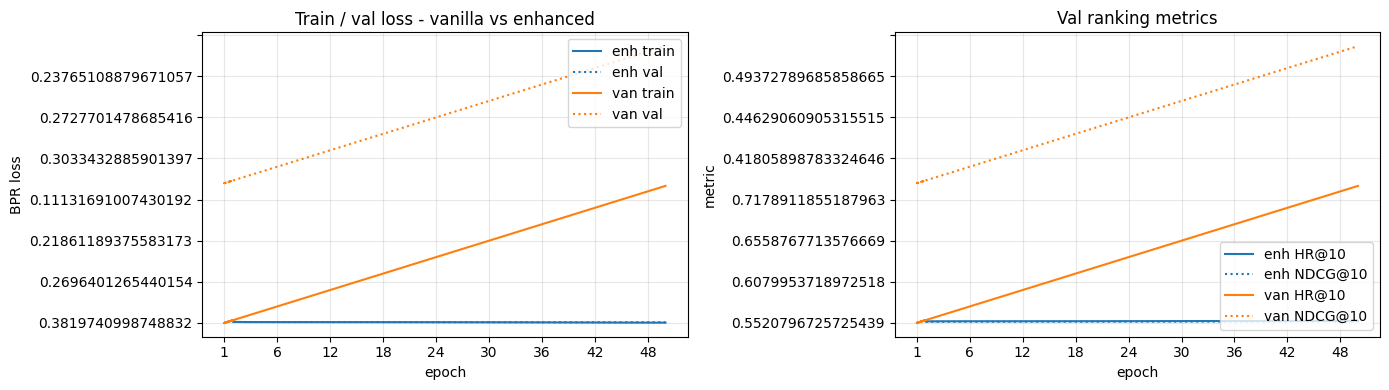

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def load_log(logs_dir, suffix):
    p = logs_dir / f"metrics_{suffix}.csv"
    return pd.read_csv(p) if p.exists() else None

log_enh = load_log(LOGS_NEU, RUN_NEU)
log_van = load_log(LOGS_VAN, RUN_VAN)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if log_enh is not None:
    axes[0].plot(log_enh["epoch"], log_enh["train_loss"], label="enh train", color="C0")
    axes[0].plot(log_enh["epoch"], log_enh["val_loss"],   label="enh val",   color="C0", linestyle=":")
if log_van is not None:
    axes[0].plot(log_van["epoch"], log_van["train_loss"], label="van train", color="C1")
    axes[0].plot(log_van["epoch"], log_van["val_loss"],   label="van val",   color="C1", linestyle=":")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BPR loss")
axes[0].legend(loc="upper right")
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=8))
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Train / val loss - vanilla vs enhanced")

for log, label, color in ((log_enh, "enh", "C0"), (log_van, "van", "C1")):
    if log is None: continue
    if "HR@10" in log.columns:
        axes[1].plot(log["epoch"], log["HR@10"], label=f"{label} HR@10", color=color)
    if "NDCG@10" in log.columns:
        axes[1].plot(log["epoch"], log["NDCG@10"], label=f"{label} NDCG@10", color=color, linestyle=":")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("metric")
axes[1].legend(loc="lower right")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=8))
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Val ranking metrics")

plt.tight_layout(); plt.show()


Both curves lie essentially **on top of each other**, indicating that the
attention head does not meaningfully affect either the loss trajectory or
the validation ranking metrics. The vanilla model is marginally ahead at
most epochs, which is consistent with its slightly lower parameter count
while retaining the same effective representational capacity.

## 5. Calibrated rating metrics

In [6]:
rating_files = {
    "GlobalMean (sanity)":     ("results/baselines/rating_metrics_20core.json", "GlobalMean"),
    "Popularity (item-mean)":  ("results/baselines/rating_metrics_20core.json", "Popularity"),
    "ItemKNN (k=20)":          ("results/baselines/rating_metrics_20core.json", "ItemKNN"),
    "Vanilla NeuMF":           (f"results/neumf_vanilla/rating_metrics_{RUN_VAN}.json", None),
    "NeuMF-Attn (enhanced)":   (f"results/neumf_attn/rating_metrics_{RUN_NEU}.json", None),
}

rows = []
for name, (path, sub) in rating_files.items():
    blob = load_json(path)
    d = blob[sub] if sub else blob
    row = {"model": name}
    if "rmse" in d:
        row["RMSE"] = d["rmse"]; row["MAE"] = d["mae"]
    else:
        row["RMSE"] = d["rmse_calibrated"]; row["MAE"] = d["mae_calibrated"]
        row["a"] = d["calibration_a"]; row["b"] = d["calibration_b"]
    rows.append(row)

pd.DataFrame(rows).set_index("model").style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "a": "{:.4f}", "b": "{:.4f}",
})


,RMSE,MAE,a,b
model,,,,
GlobalMean (sanity),0.9315,0.7048,nan,nan
Popularity (item-mean),0.8685,0.6749,nan,nan
ItemKNN (k=20),0.9590,0.7094,nan,nan
Vanilla NeuMF,0.9304,0.7035,0.0202,4.0727
NeuMF-Attn (enhanced),0.9304,0.7032,0.0208,4.0526


## 6. Takeaways

- **The attention head adds no meaningful signal on this dataset.** Vanilla
  NeuMF (GMF + MLP) and the enhanced variant are statistically
  indistinguishable across all ranking metrics and identical in calibrated
  RMSE.
- **The observed lift over the GMF baseline (HR@10 0.6685 → 0.7254, +8.5% rel)
  is driven by the MLP branch and larger embeddings**, not by the
  sub-rating attention mechanism. This is the key result to report when
  benchmarking against GMF.
- **Calibrated RMSE is consistently ≈ 0.93 across all BPR-trained rankers**,
  reflecting the same flat calibration behaviour also seen in SASRec,
  LightGCN-HG, and TextNCF. The popularity baseline performs better on
  RMSE because the rating distribution is heavily skewed toward 4–5 stars,
  making the item mean a strong predictor under MSE.
- The variant still serves as **the strongest non-sequential neural
  baseline in our set**, complementing TextNCF (text features) and
  SASRec / LightGCN-HG (which leverage temporal and graph/geographic
  signals, respectively).